# Oxford-IIIT Pet Semantic Segmentation with CNNs

This notebook is a semantic segmentation project on `data/oxford-iiit-pet`. The goal is to predict a class label for every pixel in each image using only convolutional neural network families.

The workflow is intentionally staged:

1. Build a reliable data pipeline for image and trimap mask pairs.
2. Define reusable training, metric, visualization, and grid-search utilities.
3. Run Fully Convolutional Networks (FCN) variants first as a baseline.
4. Move to U-Net, then the more expressive DeepLabv3+ segmentation architecture.
5. Select the best validation configuration, retrain it if desired, evaluate on the held-out test split, and inspect predictions.


## 1. Problem Setup and Methodology

Semantic segmentation is denser than classification. A classification CNN produces one label for an entire image, while a segmentation CNN produces a class distribution at every spatial location. This changes the project in three important ways.

**Targets.** Oxford-IIIT Pet provides trimap masks with three pixel values: pet, background, and boundary. This notebook remaps them to class indices `0`, `1`, and `2` so they can be used with `nn.CrossEntropyLoss`.

**Model outputs.** Every model returns logits with shape `[batch, classes, height, width]`. When a model computes features at a lower spatial resolution, its logits are upsampled back to the input image size with bilinear interpolation.

**Metrics.** Pixel accuracy can look good even when boundaries or small pet regions are poor. The main selection metric is therefore mean Intersection over Union, abbreviated mIoU. The notebook also tracks mean Dice score and pixel accuracy.

**Grid search.** The search is organized by model family so the simpler FCN baselines establish a reference before stronger architectures are tried. Each grid varies architecture size and, for selected families, architectural options such as skip connections or multi-scale pooling widths. The defaults are compact enough to run on a laptop; raise the sample limits or epochs for final experiments.


In [28]:
# imports
from pathlib import Path
from collections import OrderedDict
from contextlib import nullcontext
import copy
import itertools
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from torchvision import transforms
from torchvision.transforms import InterpolationMode
import torchvision.transforms.functional as TF
import pandas as pd
from tqdm.auto import tqdm
from IPython.display import display

In [29]:
# Constants and configuration
PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "data" / "oxford-iiit-pet"
IMAGES_DIR = DATA_ROOT / "images"
ANNOTATIONS_DIR = DATA_ROOT / "annotations"
TRIMAPS_DIR = ANNOTATIONS_DIR / "trimaps"

SEED = 42
IMG_SIZE = 160
BATCH_SIZE = 8
NUM_WORKERS = 0
VAL_FRACTION = 0.15
NUM_CLASSES = 3
CLASS_NAMES = ["pet", "background", "boundary"]

# Compact defaults make the grid search practical during development.
#! Set these to None and increase epochs for a full experiment.
GRID_SEARCH_MAX_TRAIN_SAMPLES = 1024
GRID_SEARCH_MAX_VAL_SAMPLES = 256
GRID_EPOCHS = 3
FINAL_EPOCHS = 10
MAX_CONFIGS_PER_STAGE = None
TRAIN_BEST_MODEL_AFTER_SEARCH = True

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP_NORM = 1.0
USE_AMP = torch.cuda.is_available()

MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"Dataset root: {DATA_ROOT}")


Using device: cuda
Dataset root: c:\Users\harpa\Documents\Github\deep-learning-1st-exercise\data\oxford-iiit-pet


## 2. Data Pipeline

The dataset is read from the official split files in `annotations/trainval.txt` and `annotations/test.txt`. Reading those split files avoids accidentally loading macOS sidecar files such as `._Abyssinian_1.png` that can appear inside extracted archives.

The training split is created from `trainval.txt` using a deterministic shuffle. Images are resized with bilinear interpolation, masks with nearest-neighbor interpolation, and the same horizontal flip is applied to both image and mask. Color jitter is applied only to the image because it should not change the segmentation target.


In [30]:
# Helpers
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def read_split_file(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            image_id = line.split()[0]
            records.append(image_id)
    return records


def filter_existing_pairs(records, image_dir=IMAGES_DIR, mask_dir=TRIMAPS_DIR):
    valid = []
    missing = []
    for image_id in records:
        image_path = image_dir / f"{image_id}.jpg"
        mask_path = mask_dir / f"{image_id}.png"
        if image_path.exists() and mask_path.exists():
            valid.append(image_id)
        else:
            missing.append(image_id)
    if missing:
        print(f"Skipped {len(missing)} records with missing image or mask files.")
    return valid


def make_pet_splits(val_fraction=VAL_FRACTION, seed=SEED):
    trainval = filter_existing_pairs(read_split_file(ANNOTATIONS_DIR / "trainval.txt"))
    test = filter_existing_pairs(read_split_file(ANNOTATIONS_DIR / "test.txt"))

    rng = random.Random(seed)
    shuffled = trainval[:]
    rng.shuffle(shuffled)
    val_count = max(1, int(len(shuffled) * val_fraction))
    val_records = shuffled[:val_count]
    train_records = shuffled[val_count:]
    return train_records, val_records, test


def take_subset(records, max_items=None, seed=SEED):
    if max_items is None or max_items >= len(records):
        return records
    rng = random.Random(seed)
    sampled = records[:]
    rng.shuffle(sampled)
    return sampled[:max_items]

In [31]:
set_seed()
train_records, val_records, test_records = make_pet_splits()
search_train_records = take_subset(train_records, GRID_SEARCH_MAX_TRAIN_SAMPLES, SEED)
search_val_records = take_subset(val_records, GRID_SEARCH_MAX_VAL_SAMPLES, SEED)

print(f"Train records: {len(train_records)}")
print(f"Validation records: {len(val_records)}")
print(f"Test records: {len(test_records)}")
print(f"Grid-search train records: {len(search_train_records)}")
print(f"Grid-search validation records: {len(search_val_records)}")


Train records: 3128
Validation records: 552
Test records: 3669
Grid-search train records: 1024
Grid-search validation records: 256


In [32]:
class SegmentationPairTransform:
    def __init__(self, image_size=IMG_SIZE, training=False):
        self.image_size = image_size
        self.training = training
        self.color_jitter = transforms.ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.10,
            hue=0.03,
        )

    def __call__(self, image, mask):
        image = TF.resize(
            image,
            [self.image_size, self.image_size],
            interpolation=InterpolationMode.BILINEAR,
        )
        mask = TF.resize(
            mask,
            [self.image_size, self.image_size],
            interpolation=InterpolationMode.NEAREST,
        )

        if self.training and random.random() < 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        if self.training:
            image = self.color_jitter(image)

        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=MEAN.flatten().tolist(), std=STD.flatten().tolist())

        mask_array = np.asarray(mask, dtype=np.int64)
        # Official trimap values are 1=pet, 2=background, 3=boundary.
        # Unknown values are mapped to background before shifting to 0-based labels.
        mask_array = np.where((mask_array >= 1) & (mask_array <= 3), mask_array, 2)
        mask_tensor = torch.from_numpy(mask_array - 1).long()
        return image, mask_tensor


class OxfordPetSegmentationDataset(Dataset):
    def __init__(self, records, image_dir=IMAGES_DIR, mask_dir=TRIMAPS_DIR, transform=None):
        self.records = list(records)
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        image_id = self.records[index]
        image_path = self.image_dir / f"{image_id}.jpg"
        mask_path = self.mask_dir / f"{image_id}.png"

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path)

        if self.transform is not None:
            image, mask = self.transform(image, mask)
        return image, mask


def make_dataloaders(train_ids, val_ids, test_ids=None, batch_size=BATCH_SIZE):
    train_dataset = OxfordPetSegmentationDataset(
        train_ids,
        transform=SegmentationPairTransform(IMG_SIZE, training=True),
    )
    val_dataset = OxfordPetSegmentationDataset(
        val_ids,
        transform=SegmentationPairTransform(IMG_SIZE, training=False),
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        drop_last=len(train_dataset) >= batch_size,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    test_loader = None
    if test_ids is not None:
        test_dataset = OxfordPetSegmentationDataset(
            test_ids,
            transform=SegmentationPairTransform(IMG_SIZE, training=False),
        )
        test_loader = DataLoader(
            test_dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=torch.cuda.is_available(),
        )

    return train_loader, val_loader, test_loader




In [33]:
search_train_loader, search_val_loader, _ = make_dataloaders(
    search_train_records,
    search_val_records,
    batch_size=BATCH_SIZE,
)

full_train_loader, full_val_loader, test_loader = make_dataloaders(
    train_records,
    val_records,
    test_records,
    batch_size=BATCH_SIZE,
)

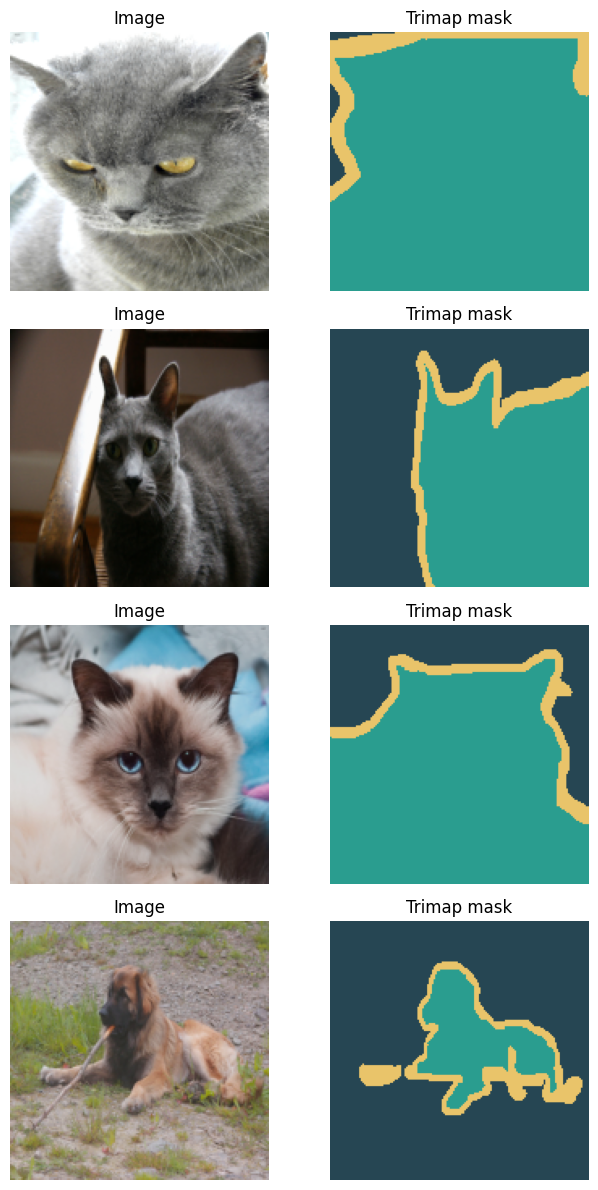

In [34]:
CLASS_COLORS = torch.tensor(
    [
        [42, 157, 143],   # pet
        [38, 70, 83],     # background
        [233, 196, 106],  # boundary
    ],
    dtype=torch.uint8,
)


def denormalize(image_tensor):
    return torch.clamp(image_tensor.cpu() * STD + MEAN, 0, 1)


def colorize_mask(mask_tensor):
    mask_tensor = mask_tensor.detach().cpu().long()
    return CLASS_COLORS[mask_tensor]


def show_batch(loader, max_items=4):
    images, masks = next(iter(loader))
    max_items = min(max_items, images.size(0))
    fig, axes = plt.subplots(max_items, 2, figsize=(7, 3 * max_items))
    if max_items == 1:
        axes = np.expand_dims(axes, axis=0)
    for i in range(max_items):
        axes[i, 0].imshow(denormalize(images[i]).permute(1, 2, 0))
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")
        axes[i, 1].imshow(colorize_mask(masks[i]))
        axes[i, 1].set_title("Trimap mask")
        axes[i, 1].axis("off")
    plt.tight_layout()


show_batch(search_train_loader, max_items=4)


## 3. Losses, Metrics, and Training Utilities

The main loss options are cross entropy and a cross-entropy plus soft-Dice hybrid.

Cross entropy is a strong default for multi-class segmentation because each pixel is treated as a supervised classification example. Dice loss directly optimizes overlap and often improves small or thin classes such as the boundary class. The hybrid loss keeps the stable gradients of cross entropy while rewarding region overlap.

The confusion matrix is accumulated on the CPU for each evaluation pass. From it we compute:

- **Pixel accuracy:** fraction of correctly classified pixels.
- **Mean IoU:** average intersection-over-union across pet, background, and boundary.
- **Mean Dice:** average Dice coefficient across the same classes.


simeiwsi:
In medical images, like cell pathology imaging, usually the cells themselves occupy the most majority of the image, if using IoU Loss, the network may chooses to predict the whole images as positive and still yields decent performance, this would make further learning hard. If Dice Loss employed, the weight of overlap in the loss definition increases, so the network would be motivated to split the cells other than learning some heuristics like the case in IoU Loss.

In [35]:
def estimate_class_weights(loader, num_classes=NUM_CLASSES):
    counts = torch.zeros(num_classes, dtype=torch.float64)
    for _, masks in tqdm(loader, desc="Estimating class weights"):
        counts += torch.bincount(masks.view(-1), minlength=num_classes).double()
    frequencies = counts / counts.sum().clamp_min(1)
    weights = 1.0 / torch.log(1.02 + frequencies)
    # print("wei" + str(weights))
    weights = weights / weights.mean()
    # print("wei" + str(weights))
    return weights.float()


class DiceCrossEntropyLoss(nn.Module):
    def __init__(self, weight=None, ce_weight=0.5, dice_weight=0.5, eps=1e-6):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=weight)
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight
        self.eps = eps

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        probabilities = torch.softmax(logits, dim=1)
        one_hot = F.one_hot(targets, num_classes=logits.shape[1]).permute(0, 3, 1, 2).float()

        dims = (0, 2, 3)
        intersection = torch.sum(probabilities * one_hot, dims)
        cardinality = torch.sum(probabilities + one_hot, dims)
        dice = (2.0 * intersection + self.eps) / (cardinality + self.eps)
        dice_loss = 1.0 - dice.mean()
        return self.ce_weight * ce_loss + self.dice_weight * dice_loss


def make_loss(loss_name="dice_ce", class_weights=None):
    if class_weights is not None:
        class_weights = class_weights.to(DEVICE)
    if loss_name == "ce":
        return nn.CrossEntropyLoss(weight=class_weights)
    if loss_name == "dice_ce":
        return DiceCrossEntropyLoss(weight=class_weights)
    raise ValueError(f"Unknown loss: {loss_name}")


def update_confusion_matrix(confmat, predictions, targets, num_classes=NUM_CLASSES):
    predictions = predictions.detach().view(-1).cpu().long()
    targets = targets.detach().view(-1).cpu().long()
    valid = (targets >= 0) & (targets < num_classes)
    indices = num_classes * targets[valid] + predictions[valid]
    confmat += torch.bincount(indices, minlength=num_classes ** 2).reshape(num_classes, num_classes)
    return confmat


def metrics_from_confusion(confmat):
    confmat = confmat.float()
    true_positive = torch.diag(confmat)
    support = confmat.sum(dim=1)
    predicted = confmat.sum(dim=0)
    union = support + predicted - true_positive

    iou = true_positive / union.clamp_min(1)
    dice = 2 * true_positive / (support + predicted).clamp_min(1)
    accuracy = true_positive.sum() / confmat.sum().clamp_min(1)

    return {
        "pixel_acc": accuracy.item(),
        "mean_iou": iou.mean().item(),
        "mean_dice": dice.mean().item(),
        "class_iou": iou.tolist(),
        "class_dice": dice.tolist(),
    }


def forward_logits(model, images, target_size):
    logits = model(images)
    if logits.shape[-2:] != target_size:
        logits = F.interpolate(logits, size=target_size, mode="bilinear", align_corners=False)
    return logits


def amp_context(enabled=USE_AMP):
    if enabled and torch.cuda.is_available():
        return torch.amp.autocast("cuda")
    return nullcontext()


def train_one_epoch(model, loader, loss_fn, optimizer, scaler=None, device=DEVICE):
    model.train()
    total_loss = 0.0
    confmat = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.long)

    for images, masks in tqdm(loader, desc="train", leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with amp_context(scaler is not None):
            logits = forward_logits(model, images, masks.shape[-2:])
            loss = loss_fn(logits, masks)

        if scaler is not None:
            scaler.scale(loss).backward()
            if GRAD_CLIP_NORM is not None:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            if GRAD_CLIP_NORM is not None:
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            optimizer.step()

        total_loss += loss.item() * images.size(0)
        predictions = logits.argmax(dim=1)
        confmat = update_confusion_matrix(confmat, predictions, masks)

    metrics = metrics_from_confusion(confmat)
    metrics["loss"] = total_loss / len(loader.dataset)
    return metrics


@torch.no_grad()
def evaluate(model, loader, loss_fn, device=DEVICE):
    model.eval()
    total_loss = 0.0
    confmat = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.long)

    for images, masks in tqdm(loader, desc="eval", leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        logits = forward_logits(model, images, masks.shape[-2:])
        loss = loss_fn(logits, masks)

        total_loss += loss.item() * images.size(0)
        predictions = logits.argmax(dim=1)
        confmat = update_confusion_matrix(confmat, predictions, masks)

    metrics = metrics_from_confusion(confmat)
    metrics["loss"] = total_loss / len(loader.dataset)
    return metrics


def fit_model(model, train_loader, val_loader, loss_fn, optimizer, epochs, scheduler=None, device=DEVICE):
    scaler = torch.amp.GradScaler("cuda") if USE_AMP else None
    history = []
    best = {
        "epoch": None,
        "val_mean_iou": -math.inf,
        "state_dict": copy.deepcopy(model.state_dict()),
    }

    for epoch in range(1, epochs + 1):
        start = time.time()
        train_metrics = train_one_epoch(model, train_loader, loss_fn, optimizer, scaler, device)
        val_metrics = evaluate(model, val_loader, loss_fn, device)
        if scheduler is not None:
            scheduler.step()

        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_miou": train_metrics["mean_iou"],
            "train_dice": train_metrics["mean_dice"],
            "val_loss": val_metrics["loss"],
            "val_miou": val_metrics["mean_iou"],
            "val_dice": val_metrics["mean_dice"],
            "val_pixel_acc": val_metrics["pixel_acc"],
            "seconds": time.time() - start,
        }
        history.append(row)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {row['train_loss']:.4f} miou {row['train_miou']:.3f} | "
            f"val loss {row['val_loss']:.4f} miou {row['val_miou']:.3f} dice {row['val_dice']:.3f}"
        )

        if val_metrics["mean_iou"] > best["val_mean_iou"]:
            best = {
                "epoch": epoch,
                "val_mean_iou": val_metrics["mean_iou"],
                "val_metrics": val_metrics,
                "state_dict": copy.deepcopy(model.state_dict()),
            }

    model.load_state_dict(best["state_dict"])
    return history, best


search_class_weights = estimate_class_weights(search_train_loader, NUM_CLASSES)
print("Search class weights:", dict(zip(CLASS_NAMES, search_class_weights.tolist())))


Estimating class weights:   0%|          | 0/128 [00:00<?, ?it/s]

Search class weights: {'pet': 0.7930542826652527, 'background': 0.46917110681533813, 'boundary': 1.7377746105194092}


## 4. CNN Architecture Families

All models below are fully convolutional. They do not use transformer blocks or pre-trained classification encoders. The point of the grid search is to compare architectural inductive biases under a shared training loop.

### FCN Baseline

A Fully Convolutional Network replaces dense classification heads with convolutional prediction heads. It is the cleanest segmentation baseline because it asks: how much can a plain encoder plus upsampling learn? The no-skip FCN tests the raw coarse decoder. The skip variant adds shallow feature predictions back into the upsampling path so fine spatial information can influence the final mask.

### U-Net

U-Net uses a symmetric encoder-decoder with skip concatenations. The encoder learns semantic context while the decoder progressively restores resolution. Concatenating encoder features into the decoder is especially helpful for object boundaries because early layers retain local edge and texture information.

### DeepLabv3+

DeepLabv3+ combines atrous convolution, Atrous Spatial Pyramid Pooling, and a lightweight decoder. Atrous convolutions increase receptive field without additional pooling, while ASPP gathers context at several dilation rates. The decoder fuses ASPP features with lower-level features to recover sharper edges.


In [36]:
# input image
# -> image normalization
# -> convolution
# -> feature normalization
# -> activation
# -> convolution
# -> feature normalization
# -> activation
# ...

# GroupNorm normalizes those intermediate activations so the next layer receives better-behaved values.
def make_group_norm(num_channels, max_groups=8):
    groups = min(max_groups, num_channels)
    while groups > 1 and (num_channels % groups != 0 or num_channels // groups < 2):
        groups -= 1
    return nn.GroupNorm(groups, num_channels)


class ConvNormAct(nn.Sequential):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=None, dilation=1):
        if padding is None:
            padding = dilation * (kernel_size // 2)
        super().__init__(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                bias=False,
            ),
            make_group_norm(out_channels),
            nn.ReLU(inplace=True),
        )


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, dilation=1):
        super().__init__()
        self.block = nn.Sequential(
            ConvNormAct(in_channels, out_channels, dilation=dilation),
            ConvNormAct(out_channels, out_channels, dilation=dilation),
        )

    def forward(self, x):
        return self.block(x)


class SimpleEncoder(nn.Module):
    def __init__(self, in_channels=3, channels=(32, 64, 128, 256)):
        super().__init__()
        self.blocks = nn.ModuleList()
        current = in_channels
        for channels_out in channels:
            self.blocks.append(DoubleConv(current, channels_out))
            current = channels_out
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        features = []
        for index, block in enumerate(self.blocks):
            x = block(x)
            features.append(x)
            if index < len(self.blocks) - 1:
                x = self.pool(x)
        return features


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


In [37]:
class FCNSegmenter(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, channels=(32, 64, 128, 256), use_skips=False, dropout=0.1):
        super().__init__()
        self.encoder = SimpleEncoder(channels=channels)
        self.use_skips = use_skips
        self.head = nn.Sequential(
            nn.Dropout2d(dropout),
            nn.Conv2d(channels[-1], num_classes, kernel_size=1),
        )
        if use_skips:
            self.laterals = nn.ModuleList([nn.Conv2d(ch, num_classes, kernel_size=1) for ch in channels[:-1]])

    def forward(self, x):
        input_size = x.shape[-2:]
        features = self.encoder(x)
        logits = self.head(features[-1])

        if self.use_skips:
            for feature, lateral in reversed(list(zip(features[:-1], self.laterals))):
                logits = F.interpolate(logits, size=feature.shape[-2:], mode="bilinear", align_corners=False)
                logits = logits + lateral(feature)

        return F.interpolate(logits, size=input_size, mode="bilinear", align_corners=False)


class UpBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, channels=(32, 64, 128, 256)):
        super().__init__()
        self.encoder = SimpleEncoder(channels=channels)
        self.decoder = nn.ModuleList(
            [
                UpBlock(channels[index], channels[index - 1], channels[index - 1])
                for index in range(len(channels) - 1, 0, -1)
            ]
        )
        self.classifier = nn.Conv2d(channels[0], num_classes, kernel_size=1)

    def forward(self, x):
        features = self.encoder(x)
        x = features[-1]
        for block, skip in zip(self.decoder, reversed(features[:-1])):
            x = block(x, skip)
        return self.classifier(x)


In [38]:
class ASPP(nn.Module):
    def __init__(self, in_channels, out_channels=128, rates=(1, 6, 12, 18), dropout=0.1):
        super().__init__()
        branches = []
        for rate in rates:
            if rate == 1:
                branches.append(ConvNormAct(in_channels, out_channels, kernel_size=1, padding=0))
            else:
                branches.append(ConvNormAct(in_channels, out_channels, kernel_size=3, dilation=rate))
        self.branches = nn.ModuleList(branches)
        self.image_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            ConvNormAct(in_channels, out_channels, kernel_size=1, padding=0),
        )
        self.project = nn.Sequential(
            ConvNormAct(out_channels * (len(rates) + 1), out_channels, kernel_size=1, padding=0),
            nn.Dropout2d(dropout),
        )

    def forward(self, x):
        size = x.shape[-2:]
        outputs = [branch(x) for branch in self.branches]
        pooled = self.image_pool(x)
        pooled = F.interpolate(pooled, size=size, mode="bilinear", align_corners=False)
        outputs.append(pooled)
        return self.project(torch.cat(outputs, dim=1))


class DeepLabV3Plus(nn.Module):
    def __init__(
        self,
        num_classes=NUM_CLASSES,
        base_channels=32,
        aspp_channels=128,
        decoder_channels=128,
        low_channels=48,
        rates=(1, 6, 12, 18),
    ):
        super().__init__()
        self.stem = DoubleConv(3, base_channels)
        self.stage2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base_channels, base_channels * 2))
        self.stage3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base_channels * 2, base_channels * 4))
        self.stage4 = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(base_channels * 4, base_channels * 8),
            ConvNormAct(base_channels * 8, base_channels * 8, dilation=2),
            ConvNormAct(base_channels * 8, base_channels * 8, dilation=4),
        )
        self.aspp = ASPP(base_channels * 8, aspp_channels, rates=rates)
        self.low_project = ConvNormAct(base_channels * 2, low_channels, kernel_size=1, padding=0)
        self.decoder = nn.Sequential(
            DoubleConv(aspp_channels + low_channels, decoder_channels),
            nn.Conv2d(decoder_channels, num_classes, kernel_size=1),
        )

    def forward(self, x):
        input_size = x.shape[-2:]
        x = self.stem(x)
        low = self.stage2(x)
        x = self.stage3(low)
        high = self.stage4(x)

        high = self.aspp(high)
        high = F.interpolate(high, size=low.shape[-2:], mode="bilinear", align_corners=False)
        low = self.low_project(low)
        logits = self.decoder(torch.cat([low, high], dim=1))
        return F.interpolate(logits, size=input_size, mode="bilinear", align_corners=False)


In [39]:
MODEL_REGISTRY = {
    "fcn": FCNSegmenter,
    "unet": UNet,
    "deeplabv3plus": DeepLabV3Plus
}


def build_model(model_name, **model_kwargs):
    if model_name not in MODEL_REGISTRY:
        raise ValueError(f"Unknown model: {model_name}")
    return MODEL_REGISTRY[model_name](num_classes=NUM_CLASSES, **model_kwargs)


@torch.no_grad()
def smoke_test_models(image_size=IMG_SIZE):
    x = torch.randn(2, 3, image_size, image_size)
    rows = []
    for name in MODEL_REGISTRY:
        model = build_model(name)
        y = model(x)
        rows.append(
            {
                "model": name,
                "parameters": count_parameters(model),
                "output_shape": tuple(y.shape),
            }
        )
    return rows


smoke_rows = smoke_test_models()
if pd is not None:
    display(pd.DataFrame(smoke_rows))
else:
    display(smoke_rows)


,model,parameters,output_shape
0,fcn,1173987,"(2, 3, 160, 160)"
1,unet,1927075,"(2, 3, 160, 160)"
2,deeplabv3plus,3741891,"(2, 3, 160, 160)"


## 5. Staged Architecture Grid Search

The grids below are intentionally explicit. Each stage has a model family, a short description, and a parameter grid. `expand_stage_grid` turns each stage into concrete experiment configurations, and `run_grid_search` trains them in order.

For quick iteration, keep `GRID_SEARCH_MAX_TRAIN_SAMPLES`, `GRID_SEARCH_MAX_VAL_SAMPLES`, and `GRID_EPOCHS` small. For final results, set both sample limits to `None`, increase `GRID_EPOCHS`, and rerun the same cells. The comparison will still be fair because every configuration uses the same split, image size, optimizer type, and metrics.


In [40]:
GRID_SEARCH_STAGES = [
    {
        "stage": "01_fcn_baseline",
        "model_name": "fcn",
        "grid": OrderedDict(
            channels=[(16, 32, 64, 128), (32, 64, 128, 256)],
            use_skips=[False, True],
            dropout=[0.1],
            lr=[1e-3],
            weight_decay=[1e-4],
            loss_name=["ce", "dice_ce"],
        ),
    },
    {
        "stage": "02_unet",
        "model_name": "unet",
        "grid": OrderedDict(
            channels=[(16, 32, 64, 128), (32, 64, 128, 256)],
            lr=[1e-3],
            weight_decay=[1e-4],
            loss_name=["dice_ce"],
        ),
    },
    {
        "stage": "03_deeplabv3plus",
        "model_name": "deeplabv3plus",
        "grid": OrderedDict(
            base_channels=[16, 24],
            aspp_channels=[64, 96],
            decoder_channels=[96],
            low_channels=[32],
            lr=[1e-3],
            weight_decay=[1e-4],
            loss_name=["dice_ce"],
        ),
    },
]

MODEL_KWARG_EXCLUDE = {"lr", "weight_decay", "loss_name"}


def expand_stage_grid(stage):
    keys = list(stage["grid"].keys())
    values = [stage["grid"][key] for key in keys]
    configs = []
    for combination in itertools.product(*values):
        raw = dict(zip(keys, combination))
        model_kwargs = {key: value for key, value in raw.items() if key not in MODEL_KWARG_EXCLUDE}
        configs.append(
            {
                "stage": stage["stage"],
                "model_name": stage["model_name"],
                "model_kwargs": model_kwargs,
                "lr": raw["lr"],
                "weight_decay": raw["weight_decay"],
                "loss_name": raw["loss_name"],
            }
        )
    if MAX_CONFIGS_PER_STAGE is not None:
        configs = configs[:MAX_CONFIGS_PER_STAGE]
    return configs


def config_name(config):
    parts = [config["stage"], config["model_name"], config["loss_name"]]
    for key, value in config["model_kwargs"].items():
        compact = str(value).replace(" ", "")
        parts.append(f"{key}={compact}")
    return " | ".join(parts)


def all_grid_configs(stages=GRID_SEARCH_STAGES):
    configs = []
    for stage in stages:
        configs.extend(expand_stage_grid(stage))
    return configs


configs_preview = [
    {
        "run": index + 1,
        "stage": config["stage"],
        "model": config["model_name"],
        "params": config["model_kwargs"],
        "loss": config["loss_name"],
        "lr": config["lr"],
    }
    for index, config in enumerate(all_grid_configs())
]

if pd is not None:
    display(pd.DataFrame(configs_preview))
else:
    display(configs_preview)


,run,stage,model,params,loss,lr
0,1,01_fcn_baseline,fcn,"{'channels': (16, 32, 64, 128), 'use_skips': F...",ce,0.001
1,2,01_fcn_baseline,fcn,"{'channels': (16, 32, 64, 128), 'use_skips': F...",dice_ce,0.001
2,3,01_fcn_baseline,fcn,"{'channels': (16, 32, 64, 128), 'use_skips': T...",ce,0.001
3,4,01_fcn_baseline,fcn,"{'channels': (16, 32, 64, 128), 'use_skips': T...",dice_ce,0.001
4,5,01_fcn_baseline,fcn,"{'channels': (32, 64, 128, 256), 'use_skips': ...",ce,0.001
5,6,01_fcn_baseline,fcn,"{'channels': (32, 64, 128, 256), 'use_skips': ...",dice_ce,0.001
6,7,01_fcn_baseline,fcn,"{'channels': (32, 64, 128, 256), 'use_skips': ...",ce,0.001
7,8,01_fcn_baseline,fcn,"{'channels': (32, 64, 128, 256), 'use_skips': ...",dice_ce,0.001
8,9,02_unet,unet,"{'channels': (16, 32, 64, 128)}",dice_ce,0.001
9,10,02_unet,unet,"{'channels': (32, 64, 128, 256)}",dice_ce,0.001


In [41]:
def run_single_experiment(config, train_loader, val_loader, class_weights, epochs=GRID_EPOCHS, seed=SEED):
    set_seed(seed)
    model = build_model(config["model_name"], **config["model_kwargs"]).to(DEVICE)
    loss_fn = make_loss(config["loss_name"], class_weights=class_weights)
    optimizer = optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"],
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, epochs))

    print("\n" + "=" * 90)
    print(config_name(config))
    print(f"Trainable parameters: {count_parameters(model):,}")

    history, best = fit_model(model, train_loader, val_loader, loss_fn, optimizer, epochs, scheduler)
    best_metrics = best["val_metrics"]
    result = {
        "stage": config["stage"],
        "model_name": config["model_name"],
        "run_name": config_name(config),
        "parameters": count_parameters(model),
        "best_epoch": best["epoch"],
        "val_loss": best_metrics["loss"],
        "val_miou": best_metrics["mean_iou"],
        "val_dice": best_metrics["mean_dice"],
        "val_pixel_acc": best_metrics["pixel_acc"],
        "config": copy.deepcopy(config),
    }
    return result, history


def run_grid_search(stages, train_loader, val_loader, class_weights, epochs=GRID_EPOCHS):
    results = []
    histories = {}
    run_index = 0

    for stage in stages:
        stage_configs = expand_stage_grid(stage)
        print(f"\n### Stage {stage['stage']} ({len(stage_configs)} configs) ###")
        for config in stage_configs:
            run_index += 1
            result, history = run_single_experiment(
                config,
                train_loader,
                val_loader,
                class_weights,
                epochs=epochs,
                seed=SEED + run_index,
            )
            results.append(result)
            histories[result["run_name"]] = history
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    return results, histories


def results_table(results):
    rows = [{key: value for key, value in result.items() if key != "config"} for result in results]
    rows = sorted(rows, key=lambda row: row["val_miou"], reverse=True)
    if pd is not None:
        return pd.DataFrame(rows)
    return rows


def best_result(results):
    return max(results, key=lambda result: result["val_miou"])


In [42]:
grid_results, grid_histories = run_grid_search(
    GRID_SEARCH_STAGES,
    search_train_loader,
    search_val_loader,
    search_class_weights,
    epochs=GRID_EPOCHS,
)

grid_summary = results_table(grid_results)
display(grid_summary)

winner = best_result(grid_results)
print("Best validation run:")
print(winner["run_name"])
print(f"mIoU={winner['val_miou']:.4f}, Dice={winner['val_dice']:.4f}, pixel accuracy={winner['val_pixel_acc']:.4f}")



### Stage 01_fcn_baseline (8 configs) ###

01_fcn_baseline | fcn | ce | channels=(16,32,64,128) | use_skips=False | dropout=0.1
Trainable parameters: 294,387


train:   0%|          | 0/128 [00:00<?, ?it/s]

eval:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 01/3 | train loss 0.9643 miou 0.354 | val loss 0.8500 miou 0.430 dice 0.580


train:   0%|          | 0/128 [00:00<?, ?it/s]

...

train:   0%|          | 0/128 [00:00<?, ?it/s]

eval:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 03/3 | train loss 0.5814 miou 0.510 | val loss 0.5547 miou 0.528 dice 0.673


,stage,model_name,run_name,parameters,best_epoch,val_loss,val_miou,val_dice,val_pixel_acc
0,03_deeplabv3plus,deeplabv3plus,03_deeplabv3plus | deeplabv3plus | dice_ce | b...,1188307,3,0.515995,0.557938,0.697833,0.773380
1,01_fcn_baseline,fcn,01_fcn_baseline | fcn | dice_ce | channels=(32...,1174668,3,0.517699,0.554130,0.695809,0.769271
2,01_fcn_baseline,fcn,01_fcn_baseline | fcn | dice_ce | channels=(16...,294732,3,0.519365,0.549646,0.692726,0.761684
3,01_fcn_baseline,fcn,"01_fcn_baseline | fcn | ce | channels=(16,32,6...",294732,3,0.662363,0.545293,0.688167,0.765222
4,03_deeplabv3plus,deeplabv3plus,03_deeplabv3plus | deeplabv3plus | dice_ce | b...,1015891,3,0.555109,0.538521,0.681546,0.768052
5,03_deeplabv3plus,deeplabv3plus,03_deeplabv3plus | deeplabv3plus | dice_ce | b...,1870539,3,0.543379,0.537618,0.680918,0.755408
6,03_deeplabv3plus,deeplabv3plus,03_deeplabv3plus | deeplabv3plus | dice_ce | b...,2102347,3,0.554692,0.528294,0.673253,0.748923
7,01_fcn_baseline,fcn,01_fcn_baseline | fcn | dice_ce | channels=(16...,294387,3,0.555237,0.521622,0.667106,0.738790
8,01_fcn_baseline,fcn,"01_fcn_baseline | fcn | ce | channels=(32,64,1...",1174668,3,0.690161,0.520445,0.668812,0.739910
9,02_unet,unet,"02_unet | unet | dice_ce | channels=(16,32,64,...",482771,3,0.586499,0.516480,0.661101,0.743010


Best validation run:
03_deeplabv3plus | deeplabv3plus | dice_ce | base_channels=16 | aspp_channels=96 | decoder_channels=96 | low_channels=32
mIoU=0.5579, Dice=0.6978, pixel accuracy=0.7734


## 6. Focused DeepLabv3+ Refinement

The first grid search identifies the strongest broad architecture family. This follow-up keeps the search focused on DeepLabv3+ and tries a slightly larger decoder, richer low-level projection, alternate atrous rates, and lower learning rates. The refinement results are merged with the original grid results, so the final retraining step still selects the best validation run overall.


In [43]:
DEEPLAB_REFINEMENT_EPOCHS = max(GRID_EPOCHS, 5)

DEEPLAB_REFINEMENT_STAGES = [
    {
        "stage": "04_deeplabv3plus_refinement",
        "model_name": "deeplabv3plus",
        "grid": OrderedDict(
            base_channels=[24, 32],
            aspp_channels=[96, 128],
            decoder_channels=[128],
            low_channels=[48],
            rates=[(1, 6, 12, 18), (1, 4, 8, 12)],
            lr=[7e-4, 5e-4],
            weight_decay=[1e-4],
            loss_name=["dice_ce"],
        ),
    },
]

deeplab_refinement_results, deeplab_refinement_histories = run_grid_search(
    DEEPLAB_REFINEMENT_STAGES,
    search_train_loader,
    search_val_loader,
    search_class_weights,
    epochs=DEEPLAB_REFINEMENT_EPOCHS,
)

combined_results = grid_results + deeplab_refinement_results
grid_histories.update(deeplab_refinement_histories)
grid_summary = results_table(combined_results)
display(grid_summary)

winner = best_result(combined_results)
print("Best validation run after DeepLabv3+ refinement:")
print(winner["run_name"])
print(f"mIoU={winner['val_miou']:.4f}, Dice={winner['val_dice']:.4f}, pixel accuracy={winner['val_pixel_acc']:.4f}")



### Stage 04_deeplabv3plus_refinement (16 configs) ###

04_deeplabv3plus_refinement | deeplabv3plus | dice_ce | base_channels=24 | aspp_channels=96 | decoder_channels=128 | low_channels=48 | rates=(1,6,12,18)
Trainable parameters: 2,223,179


train:   0%|          | 0/128 [00:00<?, ?it/s]

eval:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 01/5 | train loss 0.6952 miou 0.434 | val loss 0.6243 miou 0.482 dice 0.631


train:   0%|          | 0/128 [00:00<?, ?it/s]

...

train:   0%|          | 0/128 [00:00<?, ?it/s]

eval:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 05/5 | train loss 0.5030 miou 0.567 | val loss 0.4897 miou 0.571 dice 0.710


,stage,model_name,run_name,parameters,best_epoch,val_loss,val_miou,val_dice,val_pixel_acc
0,04_deeplabv3plus_refinement,deeplabv3plus,04_deeplabv3plus_refinement | deeplabv3plus | ...,2223179,5,0.470233,0.590545,0.725233,0.799355
1,04_deeplabv3plus_refinement,deeplabv3plus,04_deeplabv3plus_refinement | deeplabv3plus | ...,2474443,4,0.477442,0.589940,0.724382,0.799812
2,04_deeplabv3plus_refinement,deeplabv3plus,04_deeplabv3plus_refinement | deeplabv3plus | ...,2223179,5,0.481315,0.585549,0.720730,0.795745
3,04_deeplabv3plus_refinement,deeplabv3plus,04_deeplabv3plus_refinement | deeplabv3plus | ...,3431235,5,0.476427,0.585403,0.721349,0.794180
4,04_deeplabv3plus_refinement,deeplabv3plus,04_deeplabv3plus_refinement | deeplabv3plus | ...,2474443,5,0.478310,0.583909,0.719811,0.793839
5,04_deeplabv3plus_refinement,deeplabv3plus,04_deeplabv3plus_refinement | deeplabv3plus | ...,3431235,5,0.474598,0.581813,0.719587,0.788607
6,04_deeplabv3plus_refinement,deeplabv3plus,04_deeplabv3plus_refinement | deeplabv3plus | ...,3741891,5,0.479730,0.579416,0.716870,0.788083
7,04_deeplabv3plus_refinement,deeplabv3plus,04_deeplabv3plus_refinement | deeplabv3plus | ...,2474443,5,0.490993,0.579263,0.714858,0.793903
8,04_deeplabv3plus_refinement,deeplabv3plus,04_deeplabv3plus_refinement | deeplabv3plus | ...,3431235,5,0.488077,0.578372,0.714809,0.789773
9,04_deeplabv3plus_refinement,deeplabv3plus,04_deeplabv3plus_refinement | deeplabv3plus | ...,2223179,5,0.497615,0.578371,0.714637,0.793720


Best validation run after DeepLabv3+ refinement:
04_deeplabv3plus_refinement | deeplabv3plus | dice_ce | base_channels=24 | aspp_channels=96 | decoder_channels=128 | low_channels=48 | rates=(1,4,8,12)
mIoU=0.5905, Dice=0.7252, pixel accuracy=0.7994


## 7. Inspect Search Curves

The next cell plots validation mIoU for the best run from each architecture family. This is useful because two models can end with similar scores but learn at very different speeds. If a stronger architecture is still rising at the end of the compact search, it may deserve more epochs before being ruled out.


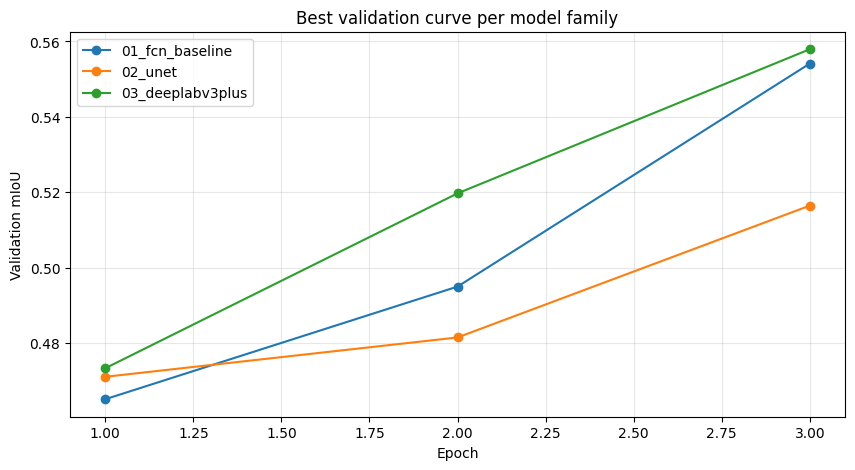

In [44]:
def plot_best_curves_by_stage(results, histories):
    best_by_stage = {}
    for result in results:
        stage = result["stage"]
        if stage not in best_by_stage or result["val_miou"] > best_by_stage[stage]["val_miou"]:
            best_by_stage[stage] = result

    plt.figure(figsize=(10, 5))
    for stage, result in best_by_stage.items():
        history = histories[result["run_name"]]
        epochs = [row["epoch"] for row in history]
        val_miou = [row["val_miou"] for row in history]
        plt.plot(epochs, val_miou, marker="o", label=stage)

    plt.xlabel("Epoch")
    plt.ylabel("Validation mIoU")
    plt.title("Best validation curve per model family")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


plot_best_curves_by_stage(grid_results, grid_histories)


## 8. Retrain the Best Configuration and Evaluate on Test Data

Grid search is usually run with smaller budgets so many options can be compared. After choosing the best validation configuration, retrain it with the full training split and evaluate once on the held-out test split. This keeps the test split clean: it is not used to choose architectures or hyperparameters.


In [45]:
def train_best_configuration(winner, epochs=FINAL_EPOCHS):
    config = winner["config"]
    full_class_weights = estimate_class_weights(full_train_loader, NUM_CLASSES)
    model = build_model(config["model_name"], **config["model_kwargs"]).to(DEVICE)
    loss_fn = make_loss(config["loss_name"], class_weights=full_class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, epochs))

    print("Retraining best configuration on the full training split:")
    print(config_name(config))
    history, best = fit_model(model, full_train_loader, full_val_loader, loss_fn, optimizer, epochs, scheduler)
    test_metrics = evaluate(model, test_loader, loss_fn, DEVICE)
    return model, history, best, test_metrics, full_class_weights


if TRAIN_BEST_MODEL_AFTER_SEARCH:
    best_model, final_history, final_best, test_metrics, full_class_weights = train_best_configuration(winner, FINAL_EPOCHS)
    print("Test metrics:")
    print({key: value for key, value in test_metrics.items() if not key.startswith("class_")})
    print("Per-class IoU:", dict(zip(CLASS_NAMES, test_metrics["class_iou"])))
else:
    best_model = None
    final_history = []
    test_metrics = None
    print("Set TRAIN_BEST_MODEL_AFTER_SEARCH=True to retrain and evaluate the selected model.")


Estimating class weights:   0%|          | 0/391 [00:00<?, ?it/s]

Retraining best configuration on the full training split:
04_deeplabv3plus_refinement | deeplabv3plus | dice_ce | base_channels=24 | aspp_channels=96 | decoder_channels=128 | low_channels=48 | rates=(1,4,8,12)


train:   0%|          | 0/391 [00:00<?, ?it/s]

eval:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch 01/10 | train loss 0.6345 miou 0.472 | val loss 0.5630 miou 0.524 dice 0.670


...

train:   0%|          | 0/391 [00:00<?, ?it/s]

eval:   0%|          | 0/69 [00:00<?, ?it/s]

Epoch 10/10 | train loss 0.3117 miou 0.706 | val loss 0.3138 miou 0.703 dice 0.812


eval:   0%|          | 0/459 [00:00<?, ?it/s]

Test metrics:
{'pixel_acc': 0.8773619532585144, 'mean_iou': 0.7126386165618896, 'mean_dice': 0.8205893039703369, 'loss': 0.3141411415609166}
Per-class IoU: {'pet': 0.7775111198425293, 'background': 0.874888002872467, 'boundary': 0.48551681637763977}


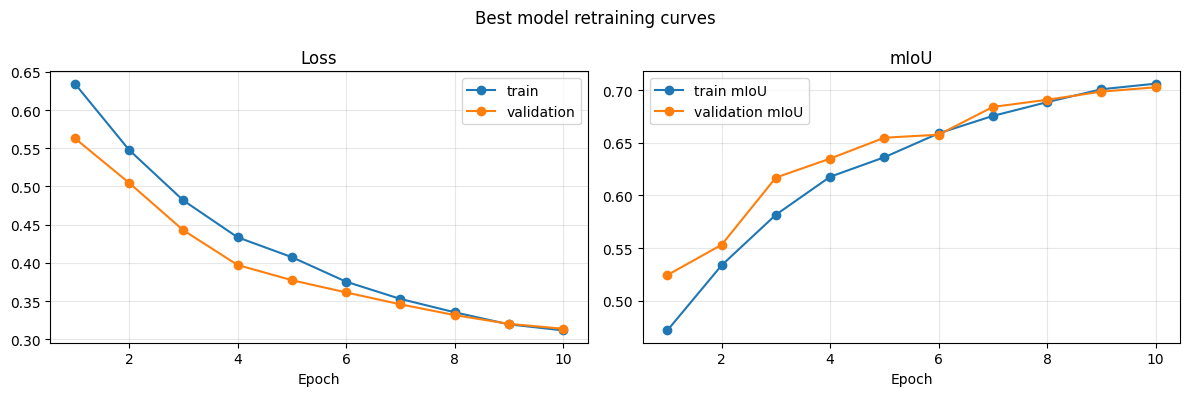

In [46]:
def plot_training_history(history, title="Training history"):
    if not history:
        print("No history to plot.")
        return

    epochs = [row["epoch"] for row in history]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, [row["train_loss"] for row in history], marker="o", label="train")
    axes[0].plot(epochs, [row["val_loss"] for row in history], marker="o", label="validation")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, [row["train_miou"] for row in history], marker="o", label="train mIoU")
    axes[1].plot(epochs, [row["val_miou"] for row in history], marker="o", label="validation mIoU")
    axes[1].set_title("mIoU")
    axes[1].set_xlabel("Epoch")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_training_history(final_history, "Best model retraining curves")


## 9. Qualitative Prediction Review

Metrics summarize performance, but segmentation models should also be inspected visually. The visualization below shows the input image, ground-truth trimap, predicted trimap, and an error map. Boundary errors are common because the boundary class is thin and annotation-sensitive, so look for whether mistakes are systematic or isolated.


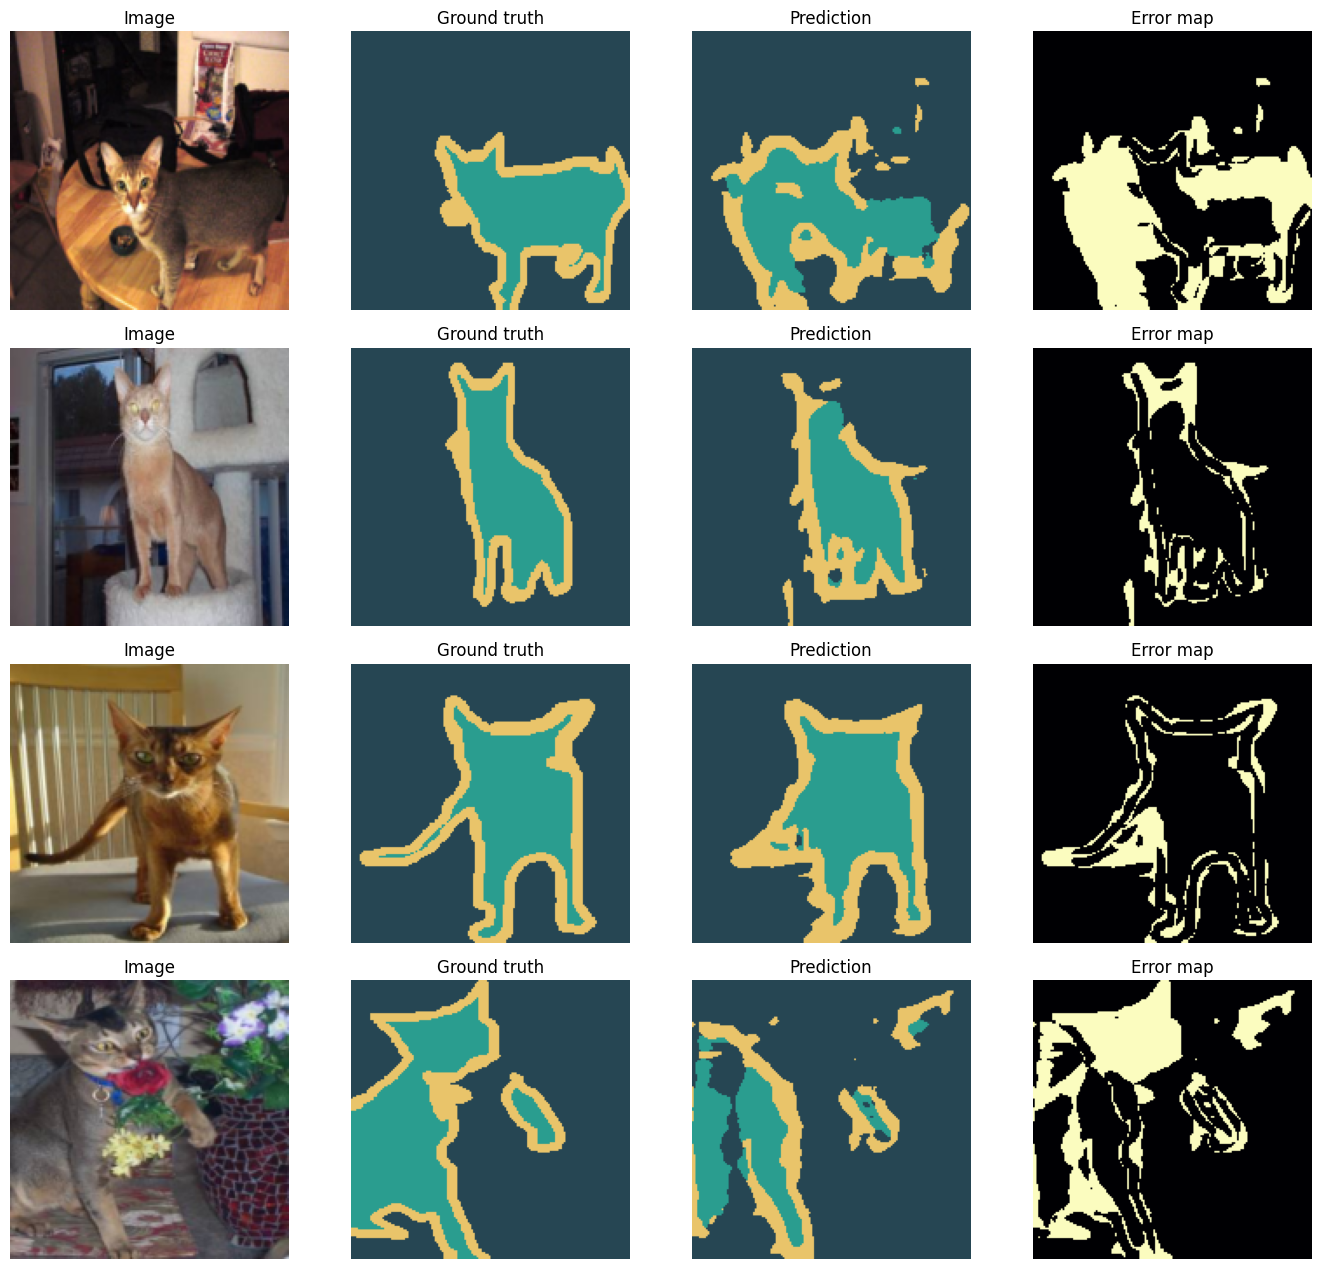

In [47]:
@torch.no_grad()
def visualize_predictions(model, loader, max_items=4, device=DEVICE):
    if model is None:
        print("No trained model is available yet.")
        return

    model.eval()
    images, masks = next(iter(loader))
    images_device = images.to(device)
    logits = forward_logits(model, images_device, masks.shape[-2:])
    predictions = logits.argmax(dim=1).cpu()

    max_items = min(max_items, images.size(0))
    fig, axes = plt.subplots(max_items, 4, figsize=(14, 3.2 * max_items))
    if max_items == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(max_items):
        error = (predictions[i] != masks[i]).long()
        axes[i, 0].imshow(denormalize(images[i]).permute(1, 2, 0))
        axes[i, 0].set_title("Image")
        axes[i, 1].imshow(colorize_mask(masks[i]))
        axes[i, 1].set_title("Ground truth")
        axes[i, 2].imshow(colorize_mask(predictions[i]))
        axes[i, 2].set_title("Prediction")
        axes[i, 3].imshow(error, cmap="magma")
        axes[i, 3].set_title("Error map")
        for axis in axes[i]:
            axis.axis("off")

    plt.tight_layout()
    plt.show()


visualize_predictions(best_model, test_loader, max_items=4)


## 10. Save the Selected CNN Segmentation Model

The checkpoint stores the model family, architecture arguments, class names, image size, normalization constants, validation metrics, and test metrics. That makes it possible to reload the model without guessing the exact grid-search configuration that produced it.


In [48]:
checkpoint_path = PROJECT_ROOT / "best_pet_segmentation_cnn.pt"

if best_model is not None:
    checkpoint = {
        "model_name": winner["config"]["model_name"],
        "model_kwargs": winner["config"]["model_kwargs"],
        "state_dict": best_model.state_dict(),
        "class_names": CLASS_NAMES,
        "image_size": IMG_SIZE,
        "mean": MEAN.flatten().tolist(),
        "std": STD.flatten().tolist(),
        "validation_metrics": final_best.get("val_metrics", None),
        "test_metrics": test_metrics,
        "grid_winner": winner,
    }
    torch.save(checkpoint, checkpoint_path)
    print(f"Saved checkpoint to: {checkpoint_path}")
else:
    print("No checkpoint saved because no final model was trained.")


Saved checkpoint to: c:\Users\harpa\Documents\Github\deep-learning-1st-exercise\best_pet_segmentation_cnn.pt


## 11. Experiment Notes and Next Steps

Use FCN as the baseline reference. If U-Net beats FCN mostly on boundaries, the skip-connections are doing useful localization work. If DeepLabv3+ improves mIoU, multi-scale context is helping the model reason about pet size and image composition. The focused refinement stage checks whether a slightly stronger DeepLabv3+ decoder and alternate atrous rates can improve on the first DeepLabv3+ pass.

For a stronger final run:

- Set `GRID_SEARCH_MAX_TRAIN_SAMPLES = None` and `GRID_SEARCH_MAX_VAL_SAMPLES = None`.
- Increase `GRID_EPOCHS` to 8-15 and `FINAL_EPOCHS` to 25 or more.
- Increase `DEEPLAB_REFINEMENT_EPOCHS` if the refinement curves are still improving.
- Increase `IMG_SIZE` to 224 if memory allows.
- Compare per-class IoU, not only overall mIoU, because boundary performance can move differently from pet/background performance.
